In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

In [63]:
# Load the dataset
df = pd.read_csv('data_set/dating_app_behavior_dataset_extended1.csv')
df.head()
# checking for dtype
df.dtypes

gender                      str
sexual_orientation          str
location_type               str
income_bracket              str
education_level             str
interest_tags               str
app_usage_time_min        int64
app_usage_time_label        str
swipe_right_ratio       float64
swipe_right_label           str
likes_received            int64
mutual_matches            int64
profile_pics_count        int64
bio_length                int64
message_sent_count        int64
emoji_usage_rate        float64
last_active_hour          int64
swipe_time_of_day           str
match_outcome               str
age                       int64
height_cm                 int64
weight_kg               float64
zodiac_sign                 str
body_type                   str
relationship_intent         str
dtype: object

gender                  0
sexual_orientation      0
location_type           0
income_bracket          0
education_level         0
interest_tags           0
app_usage_time_min      0
app_usage_time_label    0
swipe_right_ratio       0
swipe_right_label       0
likes_received          0
mutual_matches          0
profile_pics_count      0
bio_length              0
message_sent_count      0
emoji_usage_rate        0
last_active_hour        0
swipe_time_of_day       0
match_outcome           0
age                     0
height_cm               0
weight_kg               0
zodiac_sign             0
body_type               0
relationship_intent     0
dtype: int64
No. of duplicate rows: 0


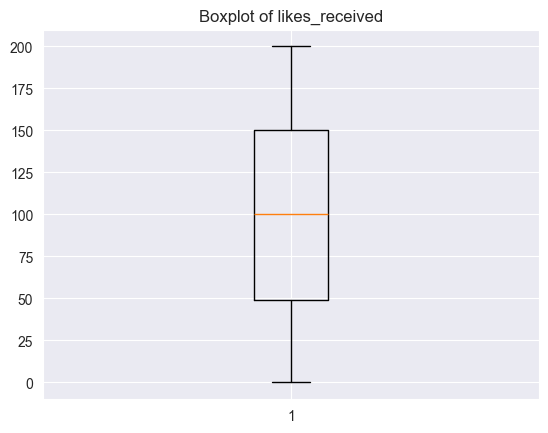

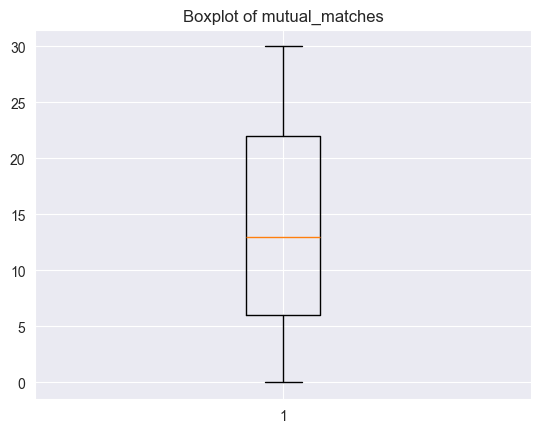

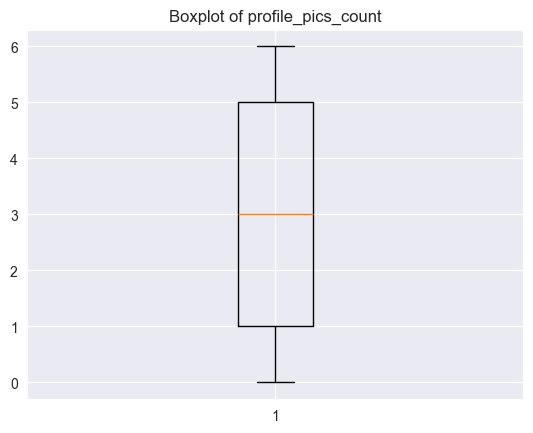

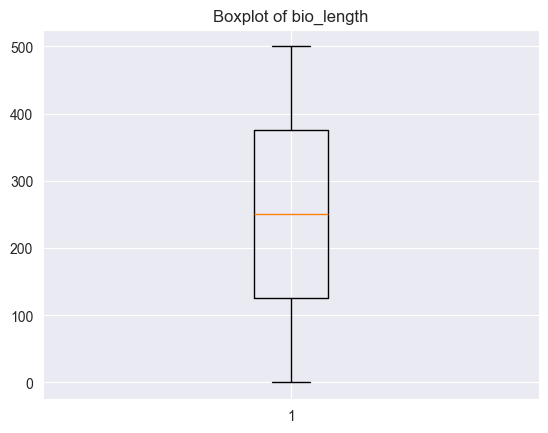

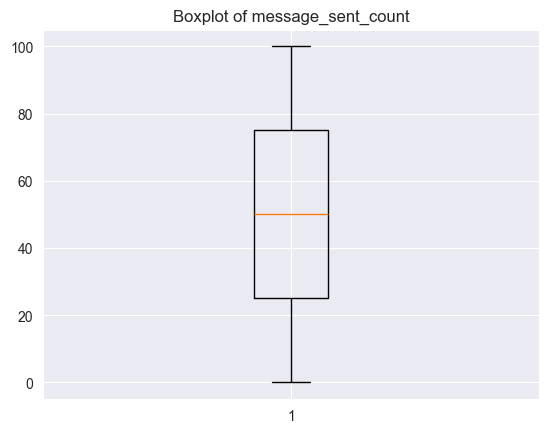

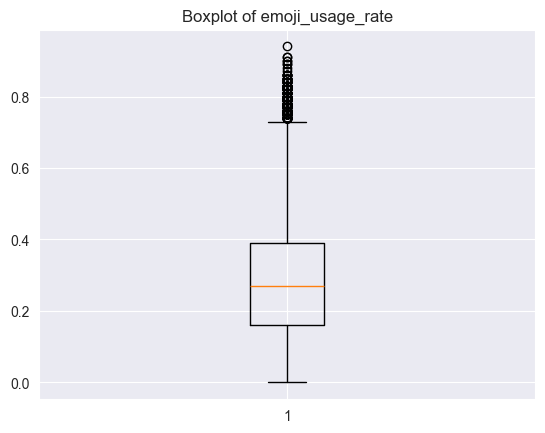

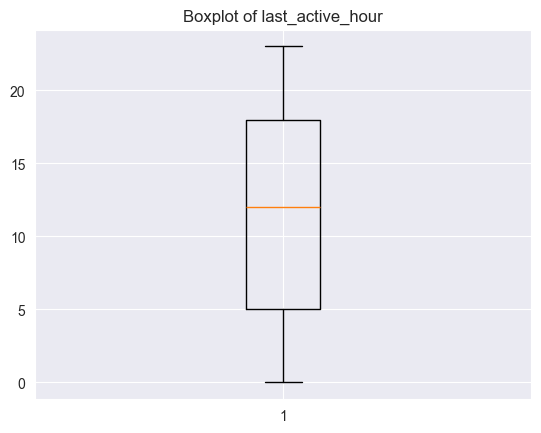

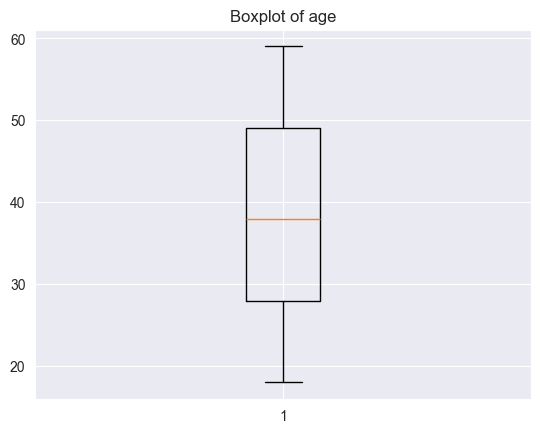

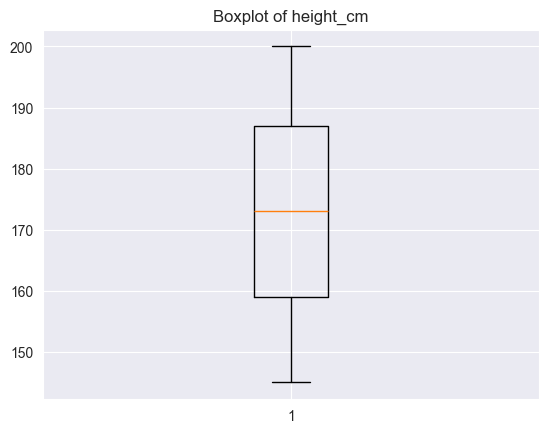

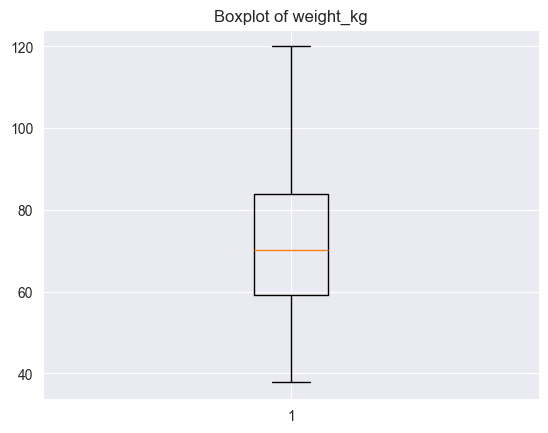

In [64]:
# Check for missing values
missing_values = df.isna().sum()
print(missing_values) # No missing values in the dataset
# checking for repeated values
duplicate_rows = df.duplicated().sum()
print(f"No. of duplicate rows: {duplicate_rows}") # No duplicate rows in the dataset
# Check for outliers in numerical values using boxplots
num_val = ["likes_received", "mutual_matches", "profile_pics_count", "bio_length", "message_sent_count", "emoji_usage_rate", "last_active_hour", "age", "height_cm", "weight_kg"]
for i in num_val:
    plt.boxplot(df[i].dropna())
    plt.title(f'Boxplot of {i}')
    plt.show()
# Only emoji_usage_rate has some outliers


In [65]:
# Encoding categorical variables
le = LabelEncoder()
df['match_outcomes'] = le.fit_transform(df['match_outcome'])

print("--- Target Variable Mapping ---")
for index, class_name in enumerate(le.classes_):
    print(f"'{class_name}' is encoded to: {index}")
print("-" * 30)

categorical_cols = ['gender', 'sexual_orientation', 'location_type', 'income_bracket',
    'education_level', 'app_usage_time_label', 'swipe_right_label',
    'swipe_time_of_day', 'zodiac_sign', 'body_type', 'relationship_intent']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

--- Target Variable Mapping ---
'Blocked' is encoded to: 0
'Catfished' is encoded to: 1
'Chat Ignored' is encoded to: 2
'Date Happened' is encoded to: 3
'Ghosted' is encoded to: 4
'Instant Match' is encoded to: 5
'Mutual Match' is encoded to: 6
'No Action' is encoded to: 7
'One-sided Like' is encoded to: 8
'Relationship Formed' is encoded to: 9
------------------------------


In [66]:
# turn into csv file for future use
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

# 2. Drop the original text target column since you now have 'match_outcomes'
if 'match_outcome' in df.columns:
    df = df.drop(columns=['match_outcome'])

# 3. Save the encoded dataset to a new CSV file
output_path = 'dating_app_behavior_encoded.csv'
df.to_csv(output_path, index=False)

print(f"\n[SUCCESS] The encoded dataset has been saved to: {output_path}")
print(f"Dataset shape: {df.shape}")


[SUCCESS] The encoded dataset has been saved to: dating_app_behavior_encoded.csv
Dataset shape: (50000, 80)


Active columns containing 'match' in your dataset: ['mutual_matches', 'match_outcomes']


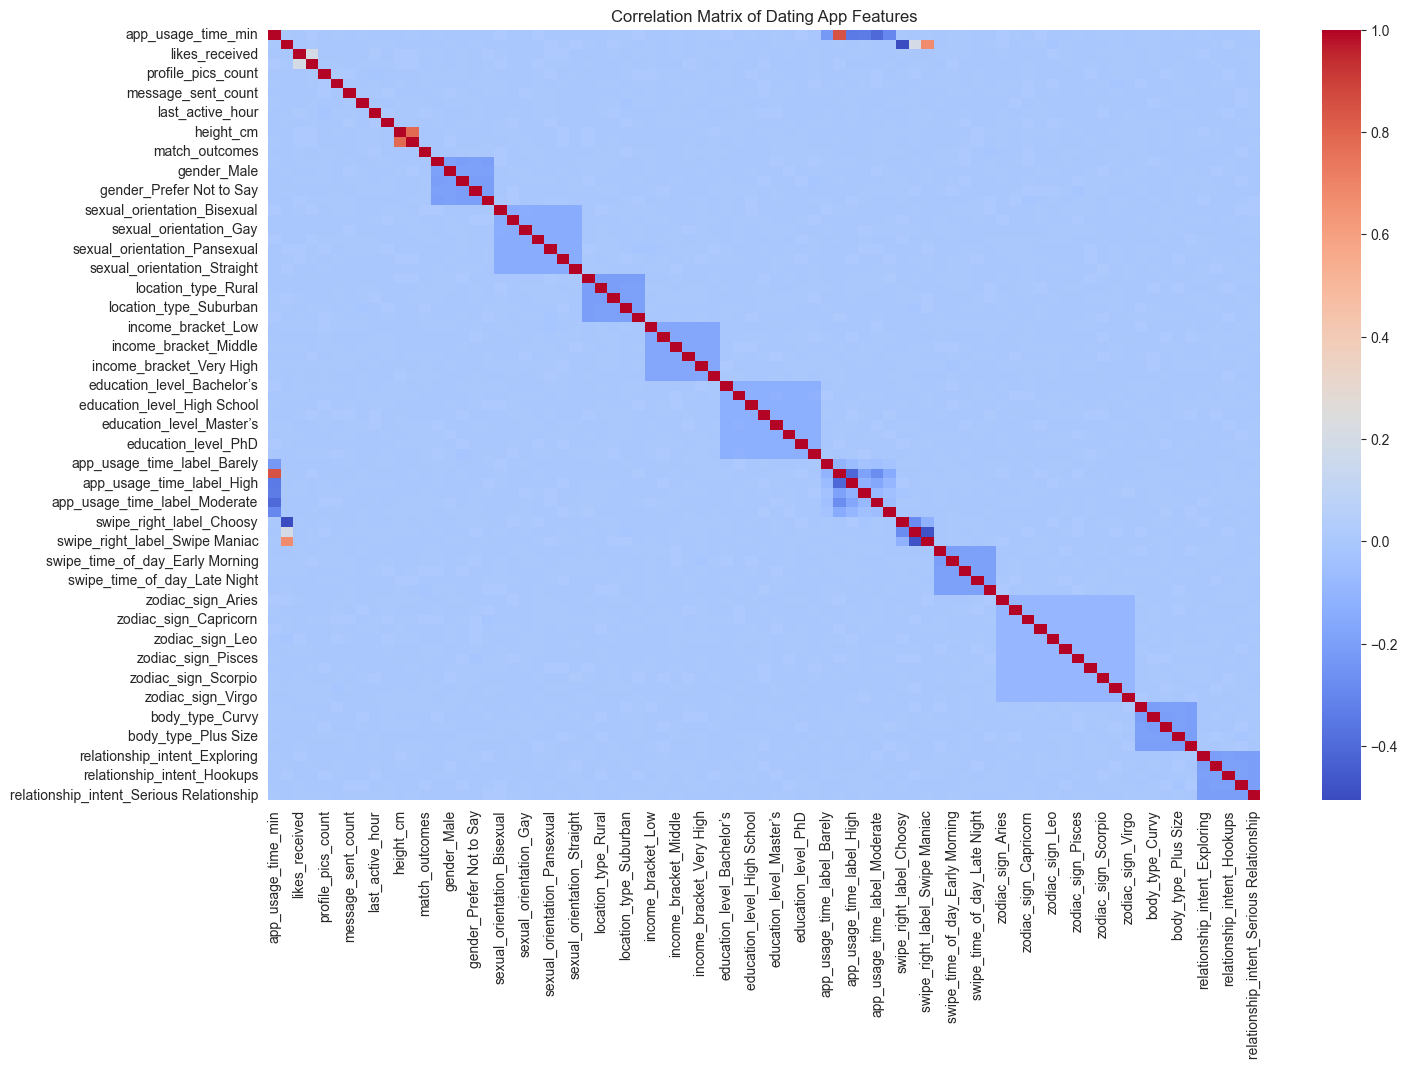


[NOTICE] 'match_outcome' was not found as a single numeric column.
It likely got split into multiple columns during One-Hot Encoding.
Printing the top correlations for each individual match category instead:

--- Top correlations for: mutual_matches ---
mutual_matches                       1.000000
likes_received                       0.205968
height_cm                            0.010265
app_usage_time_label_Extreme User    0.009291
sexual_orientation_Lesbian           0.008868
Name: mutual_matches, dtype: float64
--------------------------------------------------
--- Top correlations for: match_outcomes ---
match_outcomes                    1.000000
relationship_intent_Networking    0.008711
swipe_time_of_day_Evening         0.008582
sexual_orientation_Bisexual       0.008230
zodiac_sign_Capricorn             0.007808
Name: match_outcomes, dtype: float64
--------------------------------------------------


In [67]:
# --- DIAGNOSTIC CHECK ---
# Find exactly how 'match' columns look right now in your DataFrame
match_cols = [col for col in df.columns if 'match' in col.lower()]
print("Active columns containing 'match' in your dataset:", match_cols)

# 1. Calculate the correlation matrix
corr_matrix = df.corr(numeric_only=True)

# 2. Set up and display the heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f")
plt.title('Correlation Matrix of Dating App Features')
plt.show()

# 3. Print out the top correlations safely based on what actually exists
if 'match_outcome' in corr_matrix.columns:
    print("\n[SUCCESS] Top feature correlations with Match Outcome:")
    print(corr_matrix['match_outcome'].sort_values(ascending=False).head(10))
else:
    print("\n[NOTICE] 'match_outcome' was not found as a single numeric column.")
    print("It likely got split into multiple columns during One-Hot Encoding.")
    print("Printing the top correlations for each individual match category instead:\n")

    # Loop through and print top correlations for whatever match columns exist
    for col in match_cols:
        if col in corr_matrix.columns:
            print(f"--- Top correlations for: {col} ---")
            print(corr_matrix[col].sort_values(ascending=False).head(5))
            print("-" * 50)